In [1]:
"""
[실행 순서]
1) Cell 2: 라이브러리 설치
2) Cell 3~5: 설정/경로/run 폴더 생성
3) Cell 6: MediaPipe로 랜드마크 추출 후 캐시 파일 생성(한 번만)
4) Cell 7~11: 학습 + MLflow 로깅 + best 모델 저장
5) Cell 12: ONNX Export (웹 배포 대비)

[데이터 폴더]
- .../MediaPipe_Gaze/01.원천데이터 : 이미지(.jpg/.png/...)
- .../MediaPipe_Gaze/02.라벨링데이터 : 이미지와 같은 이름의 .json (pitch/yaw 포함)

[결과 폴더]
- .../MediaPipe_Gaze/runs/run_01/
  - features.npy, labels.npy, paths.txt (캐시)
  - split.json (train/val 분할 기록)
  - best_model.pt, last_model.pt
  - config.json
  - model.onnx (Export 결과)
"""

'\n[실행 순서]\n1) Cell 2: 라이브러리 설치\n2) Cell 3~5: 설정/경로/run 폴더 생성\n3) Cell 6: MediaPipe로 랜드마크 추출 후 캐시 파일 생성(한 번만)\n4) Cell 7~11: 학습 + MLflow 로깅 + best 모델 저장\n5) Cell 12: ONNX Export (웹 배포 대비)\n\n[데이터 폴더]\n- .../MediaPipe_Gaze/01.원천데이터 : 이미지(.jpg/.png/...)\n- .../MediaPipe_Gaze/02.라벨링데이터 : 이미지와 같은 이름의 .json (pitch/yaw 포함)\n\n[결과 폴더]\n- .../MediaPipe_Gaze/runs/run_01/\n  - features.npy, labels.npy, paths.txt (캐시)\n  - split.json (train/val 분할 기록)\n  - best_model.pt, last_model.pt\n  - config.json\n  - model.onnx (Export 결과)\n'

In [2]:
%pip install --user opencv-python

In [3]:
%pip install tqdm numpy opencv-python scikit-learn mlflow

  Using cached protobuf-6.33.5-cp310-abi3-win_amd64.whl.metadata (593 bytes)
  Using cached protobuf-4.25.8-cp310-abi3-win_amd64.whl.metadata (541 bytes)
Using cached protobuf-4.25.8-cp310-abi3-win_amd64.whl (413 kB)
  Attempting uninstall: protobuf
    Found existing installation: protobuf 3.20.3
    Uninstalling protobuf-3.20.3:
      Successfully uninstalled protobuf-3.20.3
Note: you may need to restart the kernel to use updated packages.


In [4]:
import os
import json
import math
import time
import random
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import List, Tuple, Dict, Any, Optional

import numpy as np
import cv2
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split

import mlflow

# =========================
# ✅ 재현성(같은 결과) 위해 시드 고정
# =========================
def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

# =========================
# ✅ CUDA 디바이스 설정
# =========================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE =", DEVICE)
if DEVICE.type == "cuda":
    print("CUDA =", torch.version.cuda, "| GPU =", torch.cuda.get_device_name(0))

# =========================
# ✅ (중요) 하이퍼파라미터(유저가 바꿔보는 곳)
# =========================
@dataclass
class Config:
    # ----- 데이터 -----
    train_ratio: float = 0.8
    seed: int = 42

    # ----- 랜드마크 -----
    # 눈/동공 주변만 쓰는 초경량 입력 (FaceMesh refine_landmarks=True 필요)
    # normalize_features=True면 "얼굴 크기/거리 차이"를 줄여서 학습이 안정적입니다.
    normalize_features: bool = True

    # ----- 학습 -----
    epochs: int = 30                 # ⭐️ 더 오래 돌리면 성능↑, 시간↑
    batch_size: int = 256            # ⭐️ GPU 메모리 부족하면 줄이기
    lr: float = 1e-3                 # ⭐️ 학습률 (가장 자주 튜닝)
    weight_decay: float = 1e-4       # ⭐️ 과적합 방지(너무 크면 학습이 안 될 수 있음)

    # ----- 모델(초경량 MLP) -----
    hidden_dim: int = 128            # ⭐️ 은닉층 크기
    num_layers: int = 3              # ⭐️ 레이어 수(너무 깊으면 오히려 안 좋을 때 있음)
    dropout: float = 0.1             # ⭐️ 드롭아웃(0이면 끔)

    # ----- 로깅/저장 -----
    experiment_name: str = "mediapipe_gaze_mlp"
    use_amp: bool = True             # ⭐️ CUDA면 mixed precision으로 더 빠르게(대체로 OK)

CFG = Config()
print(CFG)

DEVICE = cpu
Config(train_ratio=0.8, seed=42, normalize_features=True, epochs=30, batch_size=256, lr=0.001, weight_decay=0.0001, hidden_dim=128, num_layers=3, dropout=0.1, experiment_name='mediapipe_gaze_mlp', use_amp=True)


In [5]:
# 유저가 말한 작업 경로:
# 바탕화면/AI_video/eye_tracking/MediaPipe_Gaze
BASE_DIR = Path.home() / "Desktop" / "AI_video" / "eye_tracking" / "MediaPipe_Gaze"

RAW_DIR = BASE_DIR / "01.원천데이터"
LAB_DIR = BASE_DIR / "02.라벨링데이터"
RUNS_DIR = BASE_DIR / "runs"

assert RAW_DIR.exists(), f"원천데이터 폴더가 없습니다: {RAW_DIR}"
assert LAB_DIR.exists(), f"라벨링데이터 폴더가 없습니다: {LAB_DIR}"

RUNS_DIR.mkdir(parents=True, exist_ok=True)

def get_next_run_dir(runs_dir: Path) -> Path:
    existing = [p for p in runs_dir.glob("run_*") if p.is_dir()]
    nums = []
    for p in existing:
        try:
            nums.append(int(p.name.split("_")[1]))
        except:
            pass
    next_n = (max(nums) + 1) if nums else 1
    run_dir = runs_dir / f"run_{next_n:02d}"
    run_dir.mkdir(parents=True, exist_ok=False)
    return run_dir

RUN_DIR = get_next_run_dir(RUNS_DIR)
print("RUN_DIR =", RUN_DIR)

# 설정 저장(나중에 ONNX 변환/재현에 중요)
with open(RUN_DIR / "config.json", "w", encoding="utf-8") as f:
    json.dump(asdict(CFG), f, ensure_ascii=False, indent=2)

RUN_DIR = C:\Users\SSAFY\Desktop\AI_video\eye_tracking\MediaPipe_Gaze\runs\run_05


In [6]:
from mediapipe.python import _framework_bindings

In [7]:
%pip uninstall -y protobuf
%pip install protobuf==3.20.3

Found existing installation: protobuf 4.25.8
Uninstalling protobuf-4.25.8:
  Successfully uninstalled protobuf-4.25.8
Note: you may need to restart the kernel to use updated packages.


You can safely remove it manually.



  Using cached protobuf-3.20.3-cp310-cp310-win_amd64.whl.metadata (698 bytes)
Using cached protobuf-3.20.3-cp310-cp310-win_amd64.whl (904 kB)


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
databricks-sdk 0.96.0 requires protobuf!=5.26.*,!=5.27.*,!=5.28.*,!=5.29.0,!=5.29.1,!=5.29.2,!=5.29.3,!=5.29.4,!=6.30.0,!=6.30.1,!=6.31.0,<7.0,>=4.25.8, but you have protobuf 3.20.3 which is incompatible.
mediapipe 0.10.14 requires protobuf<5,>=4.25.3, but you have protobuf 3.20.3 which is incompatible.


In [8]:
# =========================
# ✅ 라벨 JSON에서 pitch/yaw를 최대한 "튼튼하게" 찾아내는 함수
# =========================
def _find_numeric_by_key(obj: Any, key_contains: str) -> List[float]:
    """딕셔너리/리스트 전체를 훑어서 key에 특정 문자열이 포함된 숫자값을 모읍니다."""
    found = []
    if isinstance(obj, dict):
        for k, v in obj.items():
            if isinstance(k, str) and (key_contains.lower() in k.lower()):
                if isinstance(v, (int, float)) and np.isfinite(v):
                    found.append(float(v))
            found.extend(_find_numeric_by_key(v, key_contains))
    elif isinstance(obj, list):
        for it in obj:
            found.extend(_find_numeric_by_key(it, key_contains))
    return found

def extract_pitch_yaw(label_json: Dict[str, Any]) -> Tuple[float, float]:
    """
    pitch/yaw 키 이름이 조금 달라도 최대한 찾아줍니다.
    그래도 못 찾으면, 아래 후보 키를 데이터에 맞게 1~2개 추가하면 됩니다.
    """
    # 1) 흔한 케이스: {"pitch": ..., "yaw": ...}
    if "pitch" in label_json and "yaw" in label_json:
        return float(label_json["pitch"]), float(label_json["yaw"])

    # 2) 흔한 케이스: {"pose": {"pitch":..., "yaw":...}}
    if "pose" in label_json and isinstance(label_json["pose"], dict):
        pose = label_json["pose"]
        if "pitch" in pose and "yaw" in pose:
            return float(pose["pitch"]), float(pose["yaw"])

    # 3) 재귀 탐색 (키에 pitch/yaw 문자열 포함된 숫자들 모으기)
    pitch_candidates = _find_numeric_by_key(label_json, "pitch")
    yaw_candidates   = _find_numeric_by_key(label_json, "yaw")

    # (선택) 데이터가 "y" / "p" 같은 약어면 아래처럼 후보를 늘릴 수 있음
    # pitch_candidates += _find_numeric_by_key(label_json, "p")
    # yaw_candidates   += _find_numeric_by_key(label_json, "y")

    if len(pitch_candidates) == 0 or len(yaw_candidates) == 0:
        raise KeyError("JSON에서 pitch/yaw를 찾지 못했습니다. extract_pitch_yaw() 후보 키를 데이터에 맞게 수정하세요.")

    # 여러 개면 첫 번째를 사용(대부분 문제 없음). 필요하면 규칙을 더 정교하게 바꿀 수 있음.
    return float(pitch_candidates[0]), float(yaw_candidates[0])



In [9]:
# =========================
# ✅ MediaPipe FaceMesh (iris 포함)
# =========================
import mediapipe as mp
mp_face_mesh = mp.solutions.face_mesh

# FaceMesh 인덱스(대표적으로 많이 쓰는 눈 주변 + iris)
# - 33, 133: 왼쪽 눈 바깥/안쪽 코너(대략)
# - 263, 362: 오른쪽 눈 바깥/안쪽 코너(대략)
# - refine_landmarks=True면 iris 랜드마크: 468~477
# 참고: 실제 쓰는 점 개수는 "가볍게" 유지하는 게 웹 배포에 좋아요.

LEFT_EYE_IDX = [33, 133, 159, 145, 158, 153, 160, 144]   # 최소 구성(눈꺼풀 위/아래 포함)
RIGHT_EYE_IDX = [263, 362, 386, 374, 385, 380, 387, 373]

LEFT_IRIS_IDX  = [468, 469, 470, 471, 472]
RIGHT_IRIS_IDX = [473, 474, 475, 476, 477]

# 입력에 포함할 최종 랜드마크 인덱스
SELECTED_IDX = LEFT_EYE_IDX + RIGHT_EYE_IDX + LEFT_IRIS_IDX + RIGHT_IRIS_IDX

# 정규화를 위한 기준점(양쪽 눈 바깥 코너)
ANCHOR_L = 33
ANCHOR_R = 263

class MediaPipeLandmarkExtractor:
    def __init__(self):
        # static_image_mode=True: 사진 데이터 처리용
        self.fm = mp_face_mesh.FaceMesh(
            static_image_mode=True,
            max_num_faces=1,
            refine_landmarks=True,          # ⭐️ iris 랜드마크 포함
            min_detection_confidence=0.5
        )

    def extract(self, bgr_img: np.ndarray, normalize: bool = True) -> Optional[np.ndarray]:
        """
        return: (num_points*3,) 1D 벡터 (x,y,z) * N
        - normalize=True면 얼굴 크기/거리 차이를 줄여줌(학습 안정)
        """
        if bgr_img is None:
            return None

        rgb = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2RGB)
        results = self.fm.process(rgb)

        if not results.multi_face_landmarks:
            return None

        lms = results.multi_face_landmarks[0].landmark

        # 선택한 포인트들 (x,y,z)
        pts = np.array([[lms[i].x, lms[i].y, lms[i].z] for i in SELECTED_IDX], dtype=np.float32)

        if not normalize:
            return pts.reshape(-1)

        # ===== 정규화(normalize) =====
        # 1) 양쪽 눈 바깥 코너로 얼굴 스케일 추정
        aL = np.array([lms[ANCHOR_L].x, lms[ANCHOR_L].y, lms[ANCHOR_L].z], dtype=np.float32)
        aR = np.array([lms[ANCHOR_R].x, lms[ANCHOR_R].y, lms[ANCHOR_R].z], dtype=np.float32)

        center = (aL + aR) / 2.0
        dist = np.linalg.norm(aL - aR) + 1e-6  # 0 나눗셈 방지

        pts = (pts - center) / dist
        return pts.reshape(-1)

extractor = MediaPipeLandmarkExtractor()
print("SELECTED points =", len(SELECTED_IDX), "| input_dim =", len(SELECTED_IDX)*3)

SELECTED points = 26 | input_dim = 78


In [20]:
import re
from pathlib import Path
from typing import List, Dict, Tuple
import numpy as np
import cv2
from tqdm import tqdm
import xml.etree.ElementTree as ET

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
IMG_SIZE = 64  # 64 or 96

CACHE_FEATURES = RUN_DIR / "features.npy"
CACHE_LABELS   = RUN_DIR / "labels.npy"
CACHE_PATHS    = RUN_DIR / "paths.txt"

def list_images(raw_dir: Path) -> List[Path]:
    imgs = []
    for p in raw_dir.rglob("*"):
        if p.is_file() and p.suffix.lower() in IMG_EXTS:
            imgs.append(p)
    return sorted(imgs)

def normalize_key(name: str) -> str:
    s = Path(name).stem
    s = re.sub(r'_(mod|MOD)$', '', s)
    return s

def parse_points_xy(points_str: str) -> Tuple[float, float]:
    x_str, y_str = points_str.split(",")
    return float(x_str), float(y_str)

def build_label_map_from_cvat_xml(lab_dir: Path) -> Tuple[Dict[str, Tuple[float, float]], Dict[str, int]]:
    xml_files = list(lab_dir.rglob("*.xml"))
    stats = {
        "xml_files": len(xml_files),
        "xml_parse_fail": 0,
        "images_seen": 0,
        "images_added": 0,
        "images_missing_centers": 0,
        "dup_key": 0,
    }
    label_map: Dict[str, Tuple[float, float]] = {}

    for xp in xml_files:
        try:
            root = ET.parse(xp).getroot()
        except Exception:
            stats["xml_parse_fail"] += 1
            continue

        for img in root.findall("image"):
            stats["images_seen"] += 1

            name = img.attrib.get("name")
            if not name:
                stats["images_missing_centers"] += 1
                continue

            key = normalize_key(name)

            w = float(img.attrib.get("width", "0"))
            h = float(img.attrib.get("height", "0"))
            if w <= 0 or h <= 0:
                stats["images_missing_centers"] += 1
                continue

            pts = {}
            for p in img.findall("points"):
                lbl = p.attrib.get("label")
                ps  = p.attrib.get("points")
                if lbl and ps:
                    try:
                        pts[lbl] = parse_points_xy(ps)
                    except Exception:
                        pass

            if "left_center" not in pts or "right_center" not in pts:
                stats["images_missing_centers"] += 1
                continue

            lx, ly = pts["left_center"]
            rx, ry = pts["right_center"]
            mx = (lx + rx) / 2.0
            my = (ly + ry) / 2.0

            mx_norm = mx / w
            my_norm = my / h

            if key in label_map:
                stats["dup_key"] += 1
                continue

            label_map[key] = (mx_norm, my_norm)
            stats["images_added"] += 1

    return label_map, stats

def imread_any(path: Path) -> np.ndarray | None:
    """
    ✅ Windows 경로/긴 경로/유니코드 이슈 우회:
    파일을 바이트로 읽어서 cv2.imdecode로 디코딩
    """
    try:
        data = path.read_bytes()
    except Exception:
        return None

    arr = np.frombuffer(data, dtype=np.uint8)
    img = cv2.imdecode(arr, cv2.IMREAD_UNCHANGED)
    if img is None:
        return None

    # 16-bit/float -> uint8로 정규화
    if img.dtype != np.uint8:
        img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX)
        img = img.astype(np.uint8)

    # grayscale 통일
    if img.ndim == 2:
        gray = img
    else:
        if img.shape[2] == 4:
            img = cv2.cvtColor(img, cv2.COLOR_BGRA2BGR)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    return gray

# ====== 실행 ======
images = list_images(RAW_DIR)
print("총 이미지 수 =", len(images))

label_map, xml_stats = build_label_map_from_cvat_xml(LAB_DIR)
print("라벨맵 크기 =", len(label_map))
print("XML stats =", xml_stats)

# ✅ 즉시 확인: 첫 이미지가 실제로 로드되는지
if images:
    test_img = images[0]
    print("[debug] test img:", test_img.name)
    print("[debug] normalized:", normalize_key(test_img.name))
    g = imread_any(test_img)
    print("[debug] imread_any ok?:", g is not None, None if g is None else (g.shape, g.dtype))

features = []
labels = []
paths = []

skipped_no_label = 0
skipped_bad_img  = 0

for img_path in tqdm(images):
    key = normalize_key(img_path.name)
    lab = label_map.get(key)
    if lab is None:
        skipped_no_label += 1
        continue

    gray = imread_any(img_path)
    if gray is None:
        skipped_bad_img += 1
        continue

    small = cv2.resize(gray, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)
    feat = (small.astype(np.float32) / 255.0).reshape(-1)

    features.append(feat)
    labels.append([lab[0], lab[1]])
    paths.append(str(img_path))

features_np = np.stack(features, axis=0) if features else np.zeros((0, IMG_SIZE*IMG_SIZE), dtype=np.float32)
labels_np   = np.array(labels, dtype=np.float32).reshape(-1, 2)  # ✅ (0,) 방지

print("✅ 유효 샘플 수 =", len(labels_np))
print("❌ 라벨 없음 skip =", skipped_no_label)
print("❌ 이미지 로드 실패 skip =", skipped_bad_img)

np.save(CACHE_FEATURES, features_np)
np.save(CACHE_LABELS, labels_np)
with open(CACHE_PATHS, "w", encoding="utf-8") as f:
    for p in paths:
        f.write(p + "\n")

print("캐시 저장 완료:", CACHE_FEATURES, CACHE_LABELS, CACHE_PATHS)
print("features shape:", features_np.shape, "labels shape:", labels_np.shape)

총 이미지 수 = 58368
라벨맵 크기 = 48474
XML stats = {'xml_files': 266, 'xml_parse_fail': 0, 'images_seen': 58368, 'images_added': 48474, 'images_missing_centers': 9894, 'dup_key': 0}
[debug] test img: NIA_EYE_G2_311_30_DEPTH_F_0001_mod.png
[debug] normalized: NIA_EYE_G2_311_30_DEPTH_F_0001
[debug] imread_any ok?: True ((1024, 1024), dtype('uint8'))


100%|███████████████████████████████████████████████████████████████████████████| 58368/58368 [07:55<00:00, 122.72it/s]


✅ 유효 샘플 수 = 48474
❌ 라벨 없음 skip = 9894
❌ 이미지 로드 실패 skip = 0
캐시 저장 완료: C:\Users\SSAFY\Desktop\AI_video\eye_tracking\MediaPipe_Gaze\runs\run_05\features.npy C:\Users\SSAFY\Desktop\AI_video\eye_tracking\MediaPipe_Gaze\runs\run_05\labels.npy C:\Users\SSAFY\Desktop\AI_video\eye_tracking\MediaPipe_Gaze\runs\run_05\paths.txt
features shape: (48474, 4096) labels shape: (48474, 2)


In [21]:
class LandmarkGazeDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).float()

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# 캐시 로드
X = np.load(CACHE_FEATURES)
y = np.load(CACHE_LABELS)

assert len(X) == len(y) and len(y) > 0, "유효 샘플이 없습니다. Cell 6 결과를 확인하세요."

idx_all = np.arange(len(y))
train_idx, val_idx = train_test_split(
    idx_all,
    train_size=CFG.train_ratio,
    random_state=CFG.seed,
    shuffle=True
)

# 분할 기록 저장(나중에 재현/검증용)
split_info = {
    "train_idx": train_idx.tolist(),
    "val_idx": val_idx.tolist(),
}
with open(RUN_DIR / "split.json", "w", encoding="utf-8") as f:
    json.dump(split_info, f, ensure_ascii=False, indent=2)

train_ds = LandmarkGazeDataset(X[train_idx], y[train_idx])
val_ds   = LandmarkGazeDataset(X[val_idx],   y[val_idx])

# Windows면 num_workers=0이 보통 안전합니다.
NUM_WORKERS = 0

train_loader = DataLoader(train_ds, batch_size=CFG.batch_size, shuffle=True, num_workers=NUM_WORKERS, pin_memory=(DEVICE.type=="cuda"))
val_loader   = DataLoader(val_ds,   batch_size=CFG.batch_size, shuffle=False, num_workers=NUM_WORKERS, pin_memory=(DEVICE.type=="cuda"))

input_dim = X.shape[1]
print("input_dim =", input_dim, "| train =", len(train_ds), "| val =", len(val_ds))

input_dim = 4096 | train = 38779 | val = 9695


In [22]:
class GazeMLP(nn.Module):
    """
    초경량 MLP:
    - 입력: 랜드마크 1D 벡터 (N*3)
    - 출력: [pitch, yaw]
    - ONNX로 뽑기 쉬운 기본 레이어만 사용(Linear/ReLU/Dropout/LayerNorm)
    """
    def __init__(self, input_dim: int, hidden_dim: int, num_layers: int, dropout: float):
        super().__init__()
        layers = []

        dim_in = input_dim
        for i in range(num_layers - 1):
            layers.append(nn.Linear(dim_in, hidden_dim))
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            layers.append(nn.LayerNorm(hidden_dim))  # 학습 안정에 도움
            dim_in = hidden_dim

        layers.append(nn.Linear(dim_in, 2))  # pitch, yaw
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

model = GazeMLP(
    input_dim=input_dim,
    hidden_dim=CFG.hidden_dim,
    num_layers=CFG.num_layers,
    dropout=CFG.dropout
).to(DEVICE)

print(model)

GazeMLP(
  (net): Sequential(
    (0): Linear(in_features=4096, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.1, inplace=False)
    (7): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (8): Linear(in_features=128, out_features=2, bias=True)
  )
)


In [23]:
criterion = nn.MSELoss()

def mae(pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    return (pred - target).abs().mean()

def rmse(pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    return torch.sqrt(((pred - target) ** 2).mean() + 1e-9)

def train_one_epoch(model, loader, optimizer, scaler=None):
    model.train()
    total_loss, total_mae, total_rmse = 0.0, 0.0, 0.0
    n = 0

    for Xb, yb in loader:
        Xb = Xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        if scaler is not None:
            with torch.cuda.amp.autocast():
                pred = model(Xb)
                loss = criterion(pred, yb)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            pred = model(Xb)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()

        bs = Xb.size(0)
        total_loss += loss.item() * bs
        total_mae  += mae(pred, yb).item() * bs
        total_rmse += rmse(pred, yb).item() * bs
        n += bs

    return total_loss / n, total_mae / n, total_rmse / n

@torch.no_grad()
def eval_one_epoch(model, loader):
    model.eval()
    total_loss, total_mae, total_rmse = 0.0, 0.0, 0.0
    n = 0

    for Xb, yb in loader:
        Xb = Xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)

        pred = model(Xb)
        loss = criterion(pred, yb)

        bs = Xb.size(0)
        total_loss += loss.item() * bs
        total_mae  += mae(pred, yb).item() * bs
        total_rmse += rmse(pred, yb).item() * bs
        n += bs

    return total_loss / n, total_mae / n, total_rmse / n

In [24]:
optimizer = torch.optim.AdamW(model.parameters(), lr=CFG.lr, weight_decay=CFG.weight_decay)

scaler = None
if DEVICE.type == "cuda" and CFG.use_amp:
    scaler = torch.cuda.amp.GradScaler()

# MLflow 실험 설정 (로컬이면 ./mlruns 폴더가 생깁니다)
mlflow.set_experiment(CFG.experiment_name)

# 로그에 남길 파라미터(나중에 모델 버전 비교할 때 핵심)
mlflow_params = {
    "input_dim": input_dim,
    "selected_points": len(SELECTED_IDX),
    **asdict(CFG),
    "run_dir": str(RUN_DIR),
    "device": str(DEVICE),
}
mlflow_params

2026/03/04 17:22:24 INFO mlflow.tracking.fluent: Experiment with name 'mediapipe_gaze_mlp' does not exist. Creating a new experiment.


{'input_dim': 4096,
 'selected_points': 26,
 'train_ratio': 0.8,
 'seed': 42,
 'normalize_features': True,
 'epochs': 30,
 'batch_size': 256,
 'lr': 0.001,
 'weight_decay': 0.0001,
 'hidden_dim': 128,
 'num_layers': 3,
 'dropout': 0.1,
 'experiment_name': 'mediapipe_gaze_mlp',
 'use_amp': True,
 'run_dir': 'C:\\Users\\SSAFY\\Desktop\\AI_video\\eye_tracking\\MediaPipe_Gaze\\runs\\run_05',
 'device': 'cpu'}

In [25]:
BEST_PATH = RUN_DIR / "best_model.pt"
LAST_PATH = RUN_DIR / "last_model.pt"

best_val = float("inf")

with mlflow.start_run(run_name=RUN_DIR.name):
    # 파라미터 기록
    mlflow.log_params(mlflow_params)

    for epoch in range(1, CFG.epochs + 1):
        t0 = time.time()

        tr_loss, tr_mae, tr_rmse = train_one_epoch(model, train_loader, optimizer, scaler=scaler)
        va_loss, va_mae, va_rmse = eval_one_epoch(model, val_loader)

        dt = time.time() - t0

        # 콘솔 출력(주피터에서 확인하기 편하게)
        print(f"[Epoch {epoch:03d}/{CFG.epochs}] "
              f"train: loss={tr_loss:.5f}, mae={tr_mae:.5f}, rmse={tr_rmse:.5f} | "
              f"val: loss={va_loss:.5f}, mae={va_mae:.5f}, rmse={va_rmse:.5f} | "
              f"time={dt:.1f}s")

        # MLflow metric 기록(그래프로 보기 좋게 step=epoch)
        mlflow.log_metric("train_loss", tr_loss, step=epoch)
        mlflow.log_metric("train_mae",  tr_mae,  step=epoch)
        mlflow.log_metric("train_rmse", tr_rmse, step=epoch)

        mlflow.log_metric("val_loss", va_loss, step=epoch)
        mlflow.log_metric("val_mae",  va_mae,  step=epoch)
        mlflow.log_metric("val_rmse", va_rmse, step=epoch)

        # last 저장
        torch.save({"model_state": model.state_dict(), "epoch": epoch, "config": asdict(CFG)}, LAST_PATH)

        # best 저장
        if va_loss < best_val:
            best_val = va_loss
            torch.save({"model_state": model.state_dict(), "epoch": epoch, "config": asdict(CFG)}, BEST_PATH)
            mlflow.log_metric("best_val_loss", best_val, step=epoch)

    # 학습 산출물(가중치/설정/분할/캐시)을 MLflow 아티팩트로도 저장
    mlflow.log_artifacts(str(RUN_DIR), artifact_path="artifacts")

print("✅ 학습 완료")
print("BEST:", BEST_PATH)
print("LAST:", LAST_PATH)

[Epoch 001/30] train: loss=0.04710, mae=0.13822, rmse=0.17212 | val: loss=0.00468, mae=0.05297, rmse=0.06834 | time=1.6s
[Epoch 002/30] train: loss=0.00760, mae=0.06826, rmse=0.08690 | val: loss=0.00447, mae=0.05178, rmse=0.06684 | time=1.3s
[Epoch 003/30] train: loss=0.00537, mae=0.05701, rmse=0.07316 | val: loss=0.00410, mae=0.04970, rmse=0.06402 | time=1.4s
[Epoch 004/30] train: loss=0.00449, mae=0.05209, rmse=0.06696 | val: loss=0.00353, mae=0.04657, rmse=0.05936 | time=1.5s
[Epoch 005/30] train: loss=0.00395, mae=0.04870, rmse=0.06280 | val: loss=0.00338, mae=0.04529, rmse=0.05811 | time=1.5s
[Epoch 006/30] train: loss=0.00356, mae=0.04621, rmse=0.05960 | val: loss=0.00288, mae=0.04228, rmse=0.05368 | time=2.2s
[Epoch 007/30] train: loss=0.00320, mae=0.04380, rmse=0.05652 | val: loss=0.00333, mae=0.04631, rmse=0.05772 | time=2.8s
[Epoch 008/30] train: loss=0.00290, mae=0.04160, rmse=0.05383 | val: loss=0.00279, mae=0.04223, rmse=0.05281 | time=2.6s
[Epoch 009/30] train: loss=0.002

In [28]:
%pip install -U onnx onnxscript

   ---------------------------------------- 0.0/16.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/16.4 MB ? eta -:--:--
    --------------------------------------- 0.3/16.4 MB ? eta -:--:--
    --------------------------------------- 0.3/16.4 MB ? eta -:--:--
   - -------------------------------------- 0.5/16.4 MB 989.2 kB/s eta 0:00:17
   - -------------------------------------- 0.8/16.4 MB 1.0 MB/s eta 0:00:16
   -- ------------------------------------- 1.0/16.4 MB 968.5 kB/s eta 0:00:16
   --- ------------------------------------ 1.3/16.4 MB 987.4 kB/s eta 0:00:16
   --- ------------------------------------ 1.6/16.4 MB 1.1 MB/s eta 0:00:14
   ---- ----------------------------------- 1.8/16.4 MB 1.1 MB/s eta 0:00:14
   ----- ---------------------------------- 2.1/16.4 MB 1.1 MB/s eta 0:00:13
   ----- ---------------------------------- 2.4/16.4 MB 1.1 MB/s eta 0:00:13
   ------ --------------------------------- 2.6/16.4 MB 1.2 MB/s eta 0:00:12
   ------- ----------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
databricks-sdk 0.96.0 requires protobuf!=5.26.*,!=5.27.*,!=5.28.*,!=5.29.0,!=5.29.1,!=5.29.2,!=5.29.3,!=5.29.4,!=6.30.0,!=6.30.1,!=6.31.0,<7.0,>=4.25.8, but you have protobuf 7.34.0 which is incompatible.
mediapipe 0.10.14 requires protobuf<5,>=4.25.3, but you have protobuf 7.34.0 which is incompatible.
mlflow-skinny 3.10.0 requires protobuf<7,>=3.12.0, but you have protobuf 7.34.0 which is incompatible.
mlflow-tracing 3.10.0 requires protobuf<7,>=3.12.0, but you have protobuf 7.34.0 which is incompatible.
opentelemetry-proto 1.27.0 requires protobuf<5.0,>=3.19, but you have protobuf 7.34.0 which is incompatible.


In [30]:
# best 모델 로드
ckpt = torch.load(BEST_PATH, map_location=DEVICE)
model.load_state_dict(ckpt["model_state"])
model.eval()

onnx_path = RUN_DIR / "model.onnx"

dummy = torch.randn(1, input_dim, device=DEVICE)

# ONNX 변환(가능한 표준 opset 사용)
torch.onnx.export(
    model,
    dummy,
    onnx_path.as_posix(),
    input_names=["landmarks"],
    output_names=["pitch_yaw"],
    dynamic_axes={"landmarks": {0: "batch"}, "pitch_yaw": {0: "batch"}},
    opset_version=17
)

print("✅ ONNX export 완료:", onnx_path)

C:\Users\SSAFY\AppData\Local\Temp\ipykernel_30076\352780416.py:11: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0304 17:32:31.699000 30076 site-packages\torch\onnx\_internal\exporter\_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0304 17:32:33.409000 30076 site-packages\torch\onnx\_internal\exporter\_registration.py:110] torchvision is not installed. Skipping torchvision::nms
W0304 17:32:33.426000 30076 si

[torch.onnx] Obtain model graph for `GazeMLP([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `GazeMLP([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


C:\Users\SSAFY\miniforge3\envs\mp_env\lib\copyreg.py:101: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 17).


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
✅ ONNX export 완료: C:\Users\SSAFY\Desktop\AI_video\eye_tracking\MediaPipe_Gaze\runs\run_05\model.onnx


In [29]:
# best 모델 로드
ckpt = torch.load(BEST_PATH, map_location=DEVICE)
model.load_state_dict(ckpt["model_state"])
model.eval()

onnx_path = str((RUN_DIR / "model.onnx").resolve())
dummy = torch.randn(1, input_dim, device=DEVICE)

torch.onnx.export(
    model,
    dummy,
    onnx_path,
    input_names=["features"],
    output_names=["xy"],                 # (x,y) 학습이면 이게 맞음
    dynamic_axes={"features": {0: "batch"}, "xy": {0: "batch"}},
    opset_version=17,
    dynamo=False,                        # ✅ 핵심
)

print("✅ ONNX export 완료:", onnx_path)

C:\Users\SSAFY\AppData\Local\Temp\ipykernel_30076\1248698491.py:9: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


✅ ONNX export 완료: C:\Users\SSAFY\Desktop\AI_video\eye_tracking\MediaPipe_Gaze\runs\run_05\model.onnx


In [31]:
import numpy as np
from pathlib import Path

features = np.load((RUN_DIR / "features.npy"))
labels   = np.load((RUN_DIR / "labels.npy"))

print("features:", features.shape, features.dtype)
print("labels  :", labels.shape, labels.dtype)
print("label range x:", labels[:,0].min(), "~", labels[:,0].max())
print("label range y:", labels[:,1].min(), "~", labels[:,1].max())

features: (48474, 4096) float32
labels  : (48474, 2) float32
label range x: 0.29305217 ~ 0.6383789
label range y: 0.2275754 ~ 0.7901877


In [32]:
import torch
import numpy as np

# load cache
X = np.load((RUN_DIR/"features.npy")).astype(np.float32)
Y = np.load((RUN_DIR/"labels.npy")).astype(np.float32)

# split
rng = np.random.RandomState(42)
idx = np.arange(len(X))
rng.shuffle(idx)
split = int(len(X)*0.8)
tr, va = idx[:split], idx[split:]

Xv = torch.from_numpy(X[va]).to(DEVICE)
Yv = torch.from_numpy(Y[va]).to(DEVICE)

# load best
ckpt = torch.load(BEST_PATH, map_location=DEVICE)
model.load_state_dict(ckpt["model_state"])
model.eval()

with torch.no_grad():
    pred = model(Xv).float()

mae = (pred - Yv).abs().mean(dim=0)       # (x,y) 각각 MAE
mae_all = (pred - Yv).abs().mean().item() # 전체 평균

print("MAE x,y:", mae.detach().cpu().numpy())
print("MAE mean:", mae_all)

MAE x,y: [0.01145549 0.01345299]
MAE mean: 0.012454240582883358


In [33]:
import cv2, random
import matplotlib.pyplot as plt

paths = (RUN_DIR/"paths.txt").read_text(encoding="utf-8").splitlines()

# 임의 샘플 하나
i = random.randint(0, len(paths)-1)
img_path = paths[i]

# 입력 feature / GT
x = torch.from_numpy(X[i:i+1]).to(DEVICE)
gt = Y[i]  # (0~1)

with torch.no_grad():
    pr = model(x).detach().cpu().numpy()[0]  # (0~1)

img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
if img.dtype != np.uint8:
    img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

if img.ndim == 2:
    vis = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
else:
    if img.shape[2] == 4:
        vis = cv2.cvtColor(img, cv2.COLOR_BGRA2BGR)
    else:
        vis = img.copy()

H, W = vis.shape[:2]

gt_xy = (int(gt[0]*W), int(gt[1]*H))
pr_xy = (int(pr[0]*W), int(pr[1]*H))

cv2.circle(vis, gt_xy, 6, (0,255,0), 2)  # GT green
cv2.circle(vis, pr_xy, 6, (0,0,255), 2)  # Pred red
cv2.putText(vis, "GT", (gt_xy[0]+8, gt_xy[1]-8), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0), 2)
cv2.putText(vis, "PR", (pr_xy[0]+8, pr_xy[1]+18), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,0,255), 2)

plt.figure(figsize=(5,5))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

AttributeError: 'NoneType' object has no attribute 'dtype'

In [34]:
import onnxruntime as ort
import numpy as np
import torch

onnx_path = str((RUN_DIR/"model.onnx").resolve())
sess = ort.InferenceSession(onnx_path, providers=["CPUExecutionProvider"])

# 하나 샘플
x_np = X[0:1].astype(np.float32)

# onnx
out_onnx = sess.run(None, {"features": x_np})[0]

# torch
model.eval()
with torch.no_grad():
    out_torch = model(torch.from_numpy(x_np).to(DEVICE)).cpu().numpy()

print("onnx:", out_onnx[0])
print("torch:", out_torch[0])
print("max diff:", np.max(np.abs(out_onnx - out_torch)))

ModuleNotFoundError: No module named 'onnxruntime'

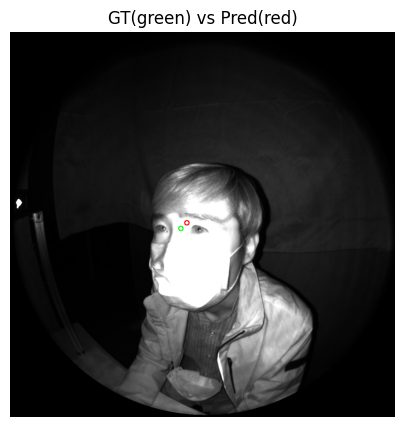

In [36]:
import cv2, random, numpy as np, torch
import matplotlib.pyplot as plt
from pathlib import Path

X = np.load((RUN_DIR/"features.npy")).astype(np.float32)
Y = np.load((RUN_DIR/"labels.npy")).astype(np.float32)
paths = (RUN_DIR/"paths.txt").read_text(encoding="utf-8").splitlines()

# best 로드
ckpt = torch.load(BEST_PATH, map_location=DEVICE)
model.load_state_dict(ckpt["model_state"])
model.eval()

i = random.randint(0, len(paths)-1)
img_path = paths[i]

with torch.no_grad():
    pred = model(torch.from_numpy(X[i:i+1]).to(DEVICE)).cpu().numpy()[0]
gt = Y[i]

img = cv2.imdecode(np.frombuffer(Path(img_path).read_bytes(), np.uint8), cv2.IMREAD_UNCHANGED)
if img.dtype != np.uint8:
    img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
vis = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR) if img.ndim==2 else (cv2.cvtColor(img, cv2.COLOR_BGRA2BGR) if img.shape[2]==4 else img.copy())

H, W = vis.shape[:2]
gt_xy = (int(gt[0]*W), int(gt[1]*H))
pr_xy = (int(pred[0]*W), int(pred[1]*H))

cv2.circle(vis, gt_xy, 6, (0,255,0), 2)  # GT
cv2.circle(vis, pr_xy, 6, (0,0,255), 2)  # Pred

plt.figure(figsize=(5,5))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("GT(green) vs Pred(red)")
plt.show()